In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

#Lload the dataset
df = pd.read_csv('github_features_clean.csv')

#separate features (X) and target (y)
X = df.drop(columns=['stargazers_count'])
y = df['stargazers_count']

y = np.log1p(y)

#split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (800, 6)
Testing data shape: (200, 6)


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

#check if we need to scale
print("Summary Statistics Before Scaling")
#select only the continuous numerical columns
continuous_cols = ['topic_count', 'forks_count_log', 'open_issues_count_log', 'days_since_last_push_log']
print(X_train[continuous_cols].describe().loc[['mean', 'std', 'min', 'max']])

#Preprocessing 
boolean_cols = ['has_projects', 'has_wiki']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_cols),
        ('bool', 'passthrough', boolean_cols)
    ])

#fit the preprocessor on the training data and transform it
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

#convert back to df just to display how it looks now
new_col_order = continuous_cols + boolean_cols
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=new_col_order, index=X_train.index)

print("\n First 3 rows of Preprocessed & Scaled Training Data")
display(X_train_scaled_df.head(3))

#verify the scaling worked
print("\n Summary Statistics After Scaling")
display(X_train_scaled_df[continuous_cols].describe().loc[['mean', 'std', 'min', 'max']].round(3))

Summary Statistics Before Scaling
      topic_count  forks_count_log  open_issues_count_log  \
mean      8.42625         8.742448               5.356359   
std       6.33816         0.925055               1.861530   
min       0.00000         2.079442               0.000000   
max      20.00000        11.607572              10.496345   

      days_since_last_push_log  
mean                  2.456175  
std                   2.038287  
min                   0.693147  
max                   7.766417  

 First 3 rows of Preprocessed & Scaled Training Data


,topic_count,forks_count_log,open_issues_count_log,days_since_last_push_log,has_projects,has_wiki
29,-0.067293,2.268540,-0.039323,1.963952,1.0,1.0
535,1.511438,-0.483948,0.767644,-0.865497,1.0,1.0
695,-0.225167,-0.932034,-1.356262,-0.865497,1.0,1.0



 Summary Statistics After Scaling


,topic_count,forks_count_log,open_issues_count_log,days_since_last_push_log
mean,0.000,-0.000,-0.000,-0.000
std,1.001,1.001,1.001,1.001
min,-1.330,-7.207,-2.879,-0.865
max,1.827,3.099,2.763,2.607


Linear Regression

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_predictions = np.expm1(lr_model.predict(X_test_scaled))

y_test_actual = np.expm1(y_test)
lr_r2 = r2_score(y_test_actual, lr_predictions)

print(f"Linear Regression R-squared: {lr_r2:.4f}")

Linear Regression R-squared: 0.3290


Random Forest Regressor

In [7]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train_scaled, y_train)

rf_predictions = np.expm1(rf_model.predict(X_test_scaled))

y_test_actual = np.expm1(y_test)
rf_r2 = r2_score(y_test_actual, rf_predictions)

print(f"Random Forest R-squared: {rf_r2:.4f}")

Random Forest R-squared: 0.2942


Gradient Boosting Regressor

In [8]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train_scaled, y_train)

gb_predictions = np.expm1(gb_model.predict(X_test_scaled))

y_test_actual = np.expm1(y_test)
gb_r2 = r2_score(y_test_actual, gb_predictions)

print(f"Gradient Boosting R-squared: {gb_r2:.4f}")

Gradient Boosting R-squared: -0.0269


Linear Regression alpha tuning

In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

print("Tuning: Ridge Regression")

param_grid_ridge = {
    'alpha': [0, 0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 200.0, 500.0],
    'fit_intercept': [True, False],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'saga']
}

grid_ridge = GridSearchCV(
    estimator=Ridge(), 
    param_grid=param_grid_ridge, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1 
)

grid_ridge.fit(X_train_scaled, y_train)

y_test_actual = np.expm1(y_test)

best_ridge = grid_ridge.best_estimator_
ridge_r2_tuned = r2_score(y_test_actual, np.expm1(best_ridge.predict(X_test_scaled)))

print(f"Best Parameters: {grid_ridge.best_params_}")
print(f"Tuned Ridge R-squared: {ridge_r2_tuned:.4f}")

Tuning: Ridge Regression
Best Parameters: {'alpha': 10.0, 'fit_intercept': True, 'solver': 'saga'}
Tuned Ridge R-squared: 0.3278


Random Forest Hyperparameter Tuning

In [10]:
print("Tuning: Random Forest Regressor")

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42), 
    param_grid=param_grid_rf, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_
rf_r2_tuned    = r2_score(y_test_actual, np.expm1(best_rf.predict(X_test_scaled)))

print(f"Best Parameters: {grid_rf.best_params_}")
print(f"Tuned Random Forest R-squared: {rf_r2_tuned:.4f}")

Tuning: Random Forest Regressor
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Random Forest R-squared: 0.3463


GB Regressor Hyperparameter Tuning

In [11]:
print("Tuning: Gradient Boosting Regressor")

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_dist_gb = {
    'n_estimators': [500, 1000],
    'learning_rate': uniform(0.01, 0.19),
    'max_depth': randint(2, 6),
    'subsample': uniform(0.5, 0.5),
    'min_samples_leaf': randint(1, 20),
    'max_features': ['sqrt', 0.7, 1.0]
}

random_gb = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_dist_gb,
    n_iter=60,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_gb.fit(X_train_scaled, y_train)

best_gb = random_gb.best_estimator_
gb_r2_tuned    = r2_score(y_test_actual, np.expm1(best_gb.predict(X_test_scaled)))

print(f"Best Parameters: {random_gb.best_params_}")
print(f"Tuned Gradient Boosting R-squared: {gb_r2_tuned:.4f}")

Tuning: Gradient Boosting Regressor
Best Parameters: {'learning_rate': np.float64(0.01978096273749798), 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500, 'subsample': np.float64(0.8403527257773834)}
Tuned Gradient Boosting R-squared: 0.3088


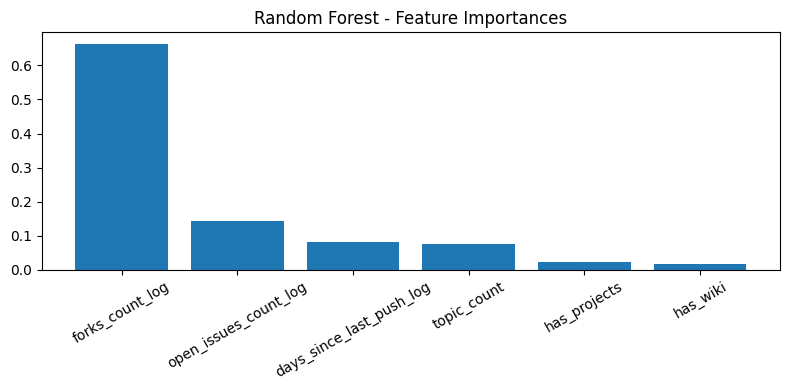

In [12]:
import matplotlib.pyplot as plt

feature_names = continuous_cols + boolean_cols

#best rf model importnaces
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
plt.bar(range(len(feature_names)), importances[indices])
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=30)
plt.title("Random Forest - Feature Importances")
plt.tight_layout()
plt.show()

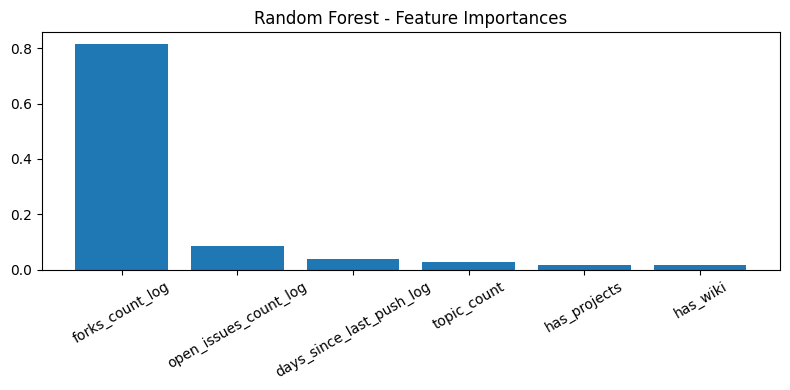

In [13]:
import matplotlib.pyplot as plt

feature_names = continuous_cols + boolean_cols

#best gb model importances
importances = best_gb.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
plt.bar(range(len(feature_names)), importances[indices])
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=30)
plt.title("Random Forest - Feature Importances")
plt.tight_layout()
plt.show()

In [14]:
results = pd.DataFrame({
    'Model':    ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'Baseline R²': [lr_r2, rf_r2, gb_r2],
    'Tuned R²':    [ridge_r2_tuned, rf_r2_tuned, gb_r2_tuned],
    'Improvement': [ridge_r2_tuned - lr_r2, rf_r2_tuned - rf_r2, gb_r2_tuned - gb_r2]
})
results = results.sort_values('Tuned R²', ascending=False).reset_index(drop=True)
display(results.round(4))


,Model,Baseline R²,Tuned R²,Improvement
0,Random Forest,0.2942,0.3463,0.0521
1,Linear Regression,0.3290,0.3278,-0.0012
2,Gradient Boosting,-0.0269,0.3088,0.3357


In [15]:
import joblib

y_test_actual = np.expm1(y_test)

models = {
    'Ridge':            (best_ridge, 'ridge_model.pkl'),
    'Random Forest':    (best_rf,    'rf_model.pkl'),
    'Gradient Boosting':(best_gb,    'gb_model.pkl'),
}

results_overfitting = []

for name, (model, filename) in models.items():
    train_r2 = r2_score(np.expm1(y_train), np.expm1(model.predict(X_train_scaled)))
    test_r2  = r2_score(y_test_actual,      np.expm1(model.predict(X_test_scaled)))
    gap      = train_r2 - test_r2

    results_overfitting.append({
        'Model':    name,
        'Train R²': round(train_r2, 4),
        'Test R²':  round(test_r2, 4),
        'Gap':      round(gap, 4),
        'Status':   'overfitting' if gap > 0.1 else 'ok'
    })

    joblib.dump(model, filename)
    print(f"Saved {name} -> {filename}")

joblib.dump(preprocessor, 'preprocessor.pkl')
print("Saved preprocessor -> preprocessor.pkl")

print("\nOverfitting Check")
display(pd.DataFrame(results_overfitting))

Saved Ridge -> ridge_model.pkl
Saved Random Forest -> rf_model.pkl
Saved Gradient Boosting -> gb_model.pkl
Saved preprocessor -> preprocessor.pkl

Overfitting Check


,Model,Train R²,Test R²,Gap,Status
0,Ridge,0.3425,0.3278,0.0147,ok
1,Random Forest,0.7277,0.3463,0.3814,overfitting
2,Gradient Boosting,0.6596,0.3088,0.3508,overfitting


Summary:

Ridge Regression performed the best overall, despite no thaving the highest R2 scor eon the test set. Because predicting GitHub popularity is inherently noisy, Ridge's simplicity and penalty constraints allowed it to capture baseline trends without memorizing the noise.

Both Random Forest and Gradient Boosting struggled significantly. Because the dataset is small (1,000 rows) and GitHub star counts are highly volatile, these complex models overfit the training data. 

The best model achieved an R2 of 0.3290 (original linear regressino without L2 regularization). Only about 31% of a repository's popularity can be explained by structural metadata like forks, issues, and topics. 

To improve prediction accuracy in future iterations, the pipeline would need a vastly larger dataset or the integration of external viral features (e.g., social media mentions, Hacker News trends) that drive real-world GitHub popularity.